### Importing necessary Libraries

In [1]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
)

from imblearn.over_sampling import SMOTE


## Reading Csv file

In [2]:
df=pd.read_csv('creditcard.csv')

## Displaying first 5 rows of dataset

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Displaying last 5 rows of dataset

In [4]:
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


## Displaying the numbers of rows and features of dataset

In [5]:
df.shape

(284807, 31)

In [6]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [7]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [9]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [10]:
df.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

## Feature Engineering

In [11]:
df['hour'] = (df['Time']//3600)%24
df['is_night'] = ((df['hour']<=6) | (df['hour']>=22)).astype(int)
df['amt_log'] = np.log1p(df['Amount'])

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df.shape

(283726, 34)

In [14]:
df['Class'].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

## Exploratary Data Analysis

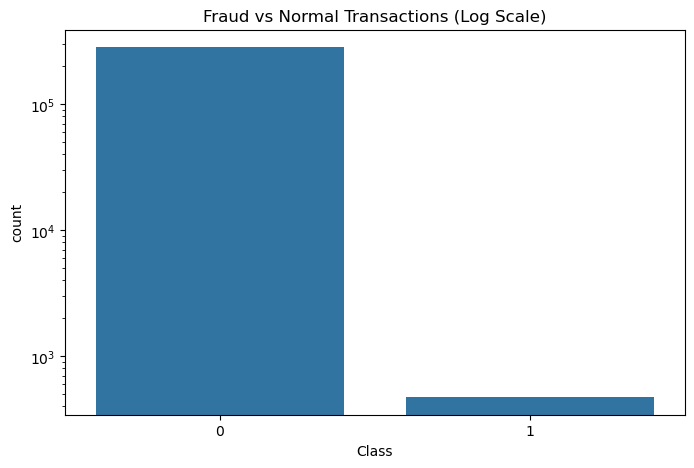

In [16]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Class',
    data=df
)

plt.yscale('log')

plt.title('Fraud vs Normal Transactions (Log Scale)')
plt.show()

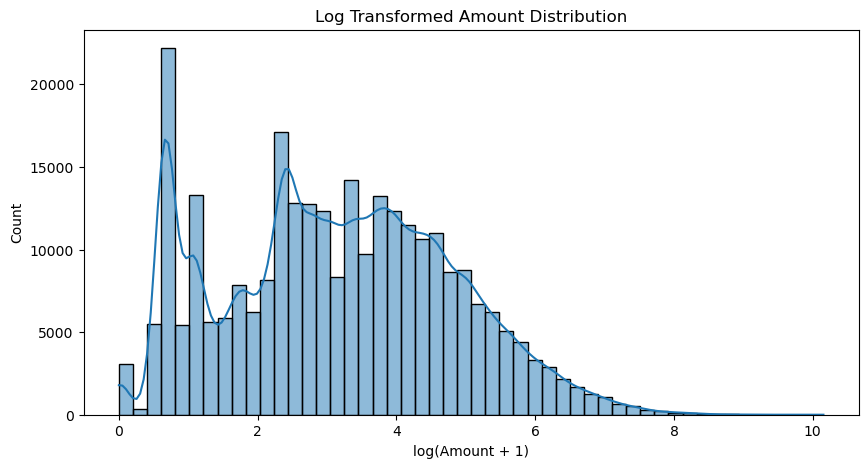

In [17]:
plt.figure(figsize=(10,5))

sns.histplot(
    np.log1p(df['Amount']),
    bins=50,
    kde=True
)

plt.title('Log Transformed Amount Distribution')
plt.xlabel('log(Amount + 1)')
plt.show()

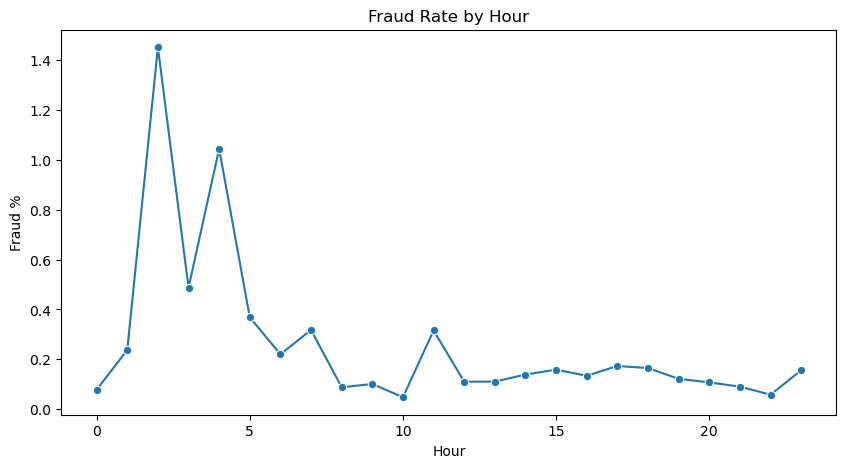

In [18]:
hourly_fraud = df.groupby('hour')['Class'].mean()*100

plt.figure(figsize=(10,5))

sns.lineplot(
    x=hourly_fraud.index,
    y=hourly_fraud.values,
    marker='o'
)

plt.title('Fraud Rate by Hour')
plt.ylabel('Fraud %')
plt.xlabel('Hour')
plt.show()

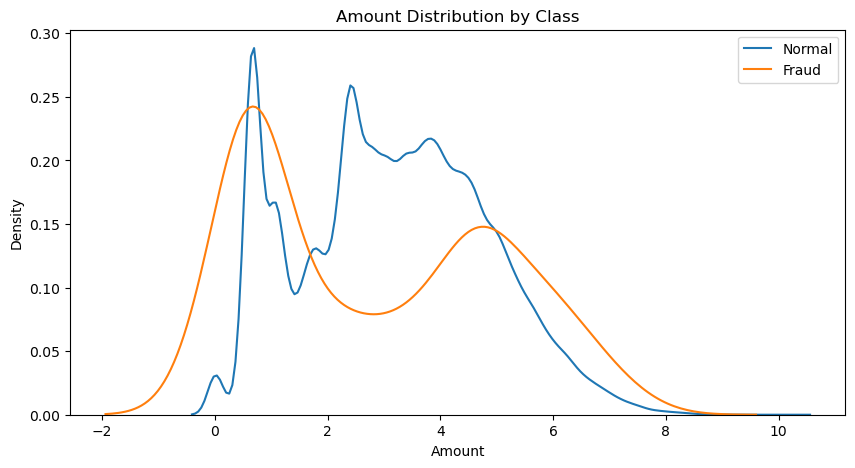

In [19]:
plt.figure(figsize=(10,5))

sns.kdeplot(
    np.log1p(df[df['Class']==0]['Amount']),
    label='Normal'
)

sns.kdeplot(
    np.log1p(df[df['Class']==1]['Amount']),
    label='Fraud'
)

plt.legend()
plt.title('Amount Distribution by Class')
plt.show()

## Correlation between Features

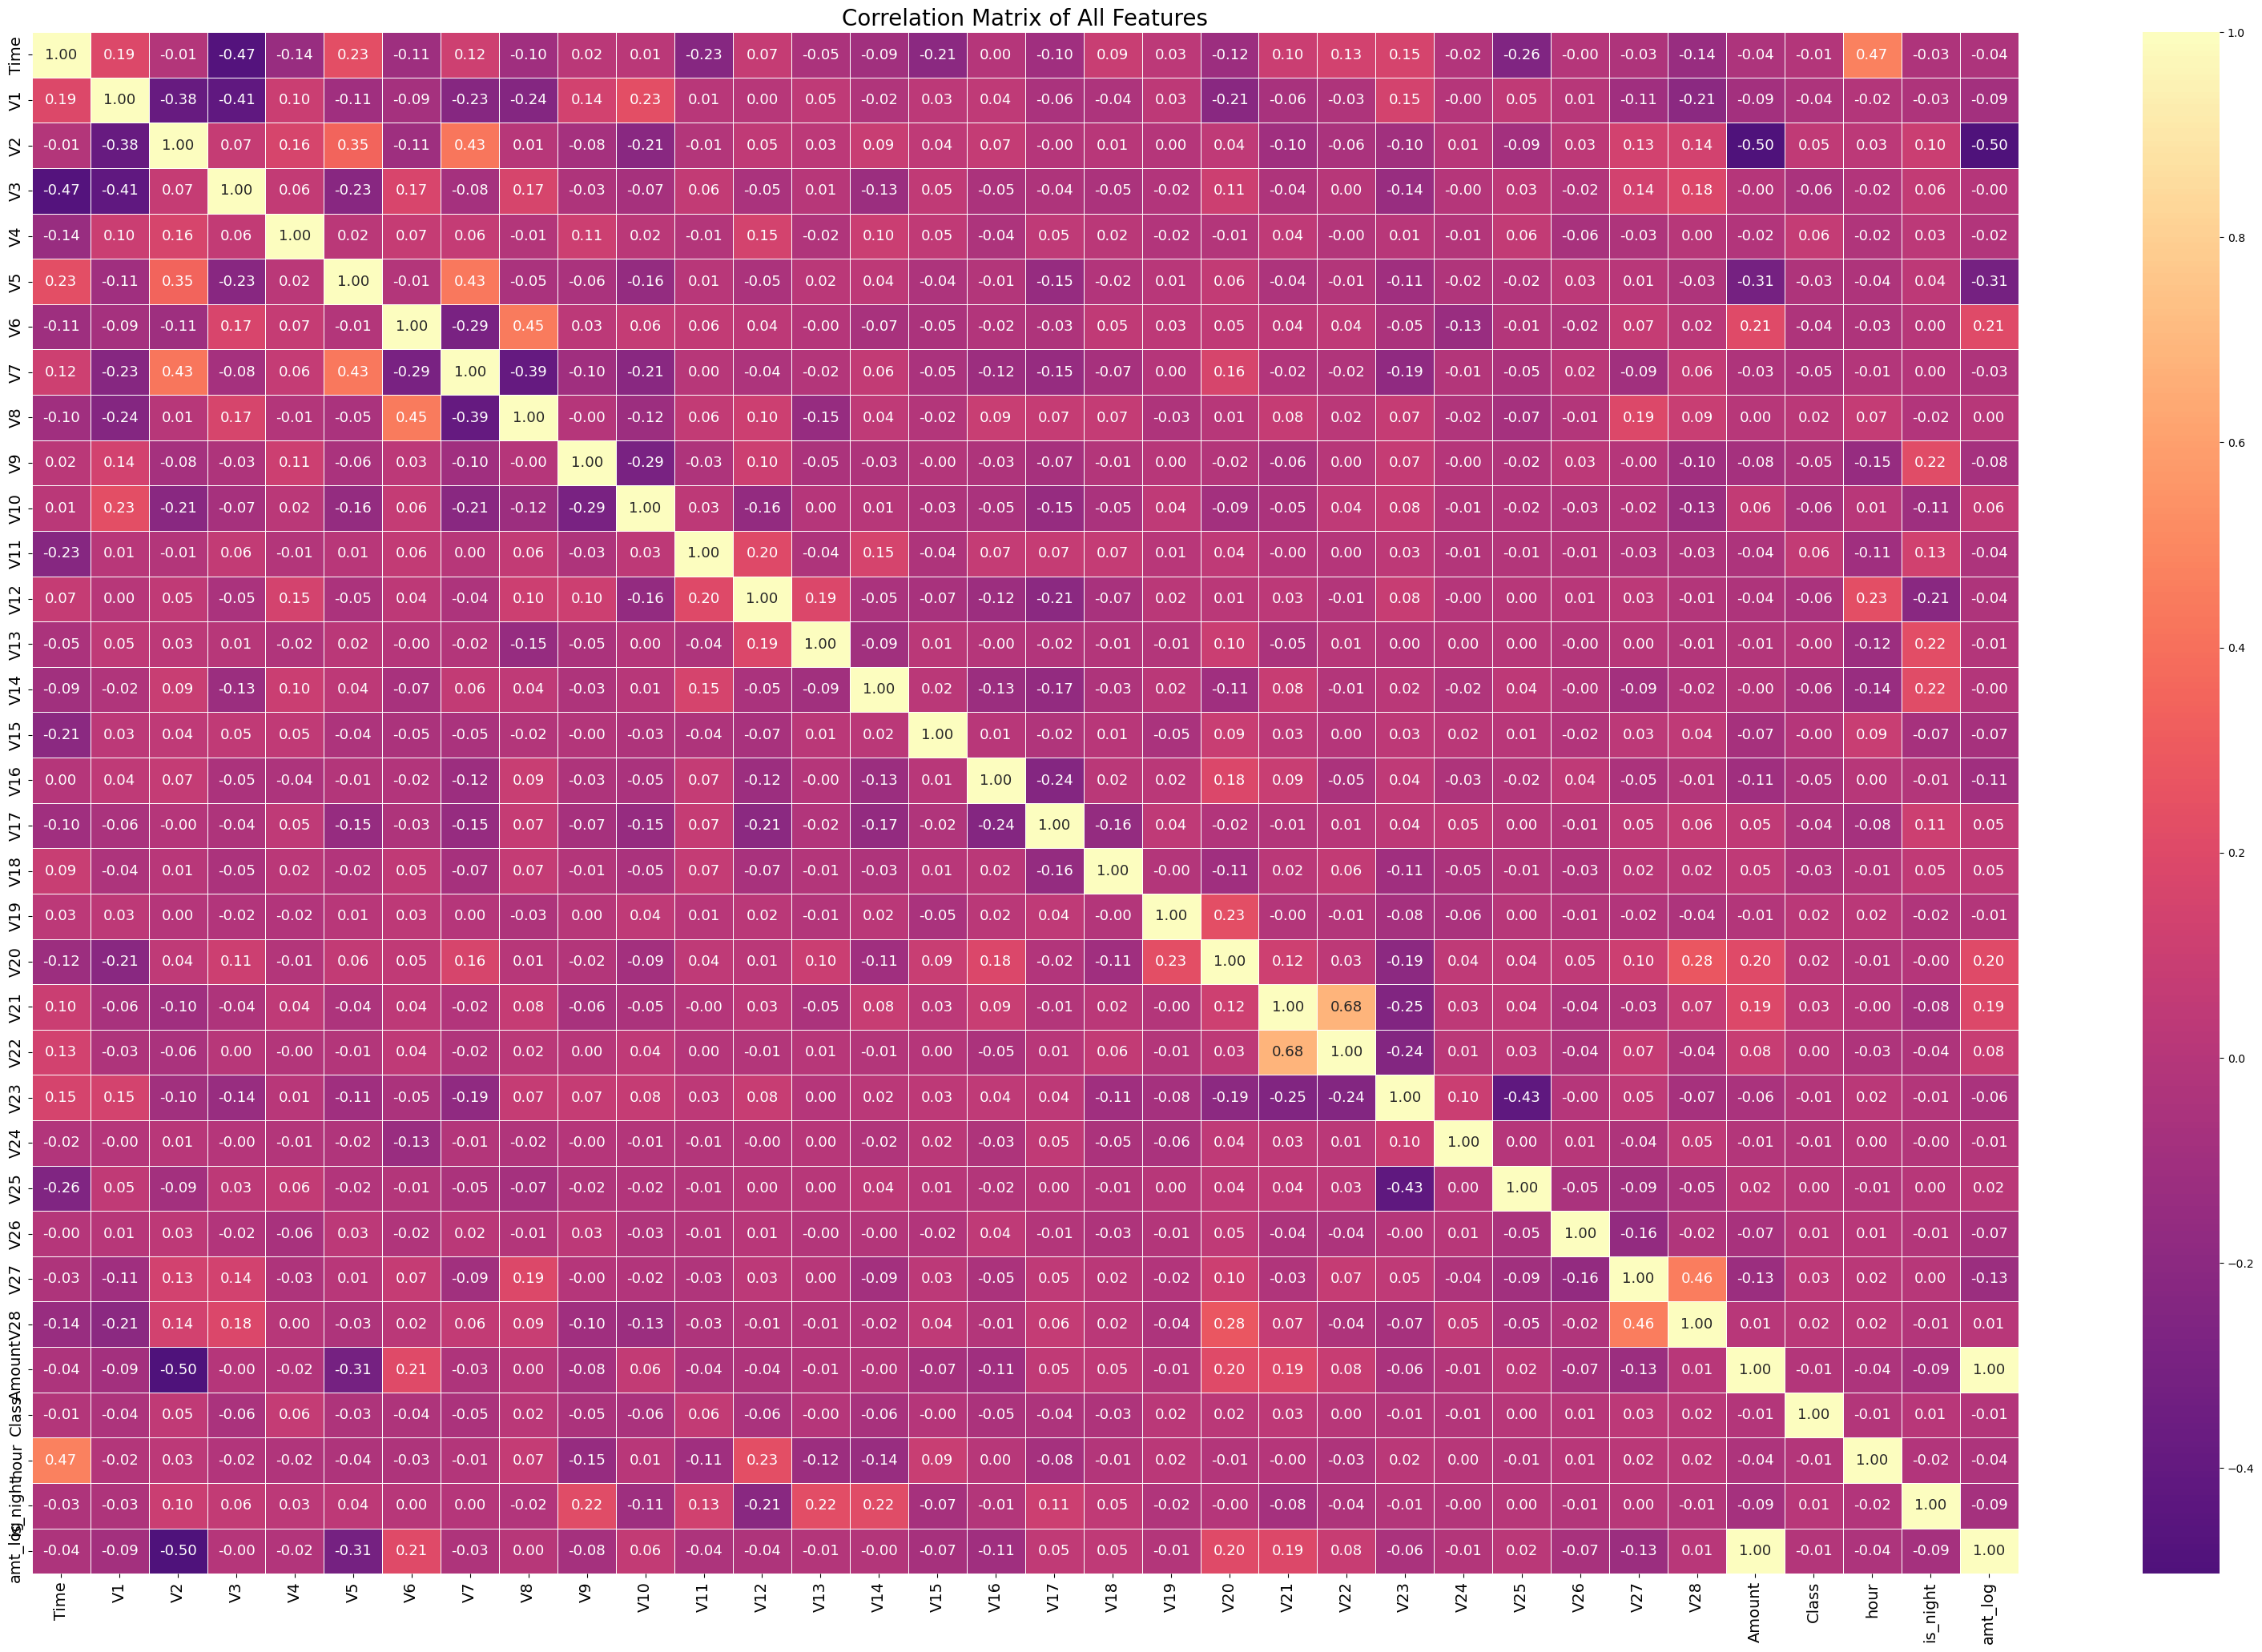

In [20]:
spearman_corr = df.corr(method='spearman')


plt.figure(figsize=(40,25))
sns.heatmap(
    spearman_corr,
    cmap='magma',
    center=0,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 13},
    linewidths=0.5
)

plt.xticks(fontsize=14, rotation=90)
plt.yticks(fontsize=14)
plt.title('Correlation Matrix of All Features', fontsize=20)

plt.show()

<Axes: >

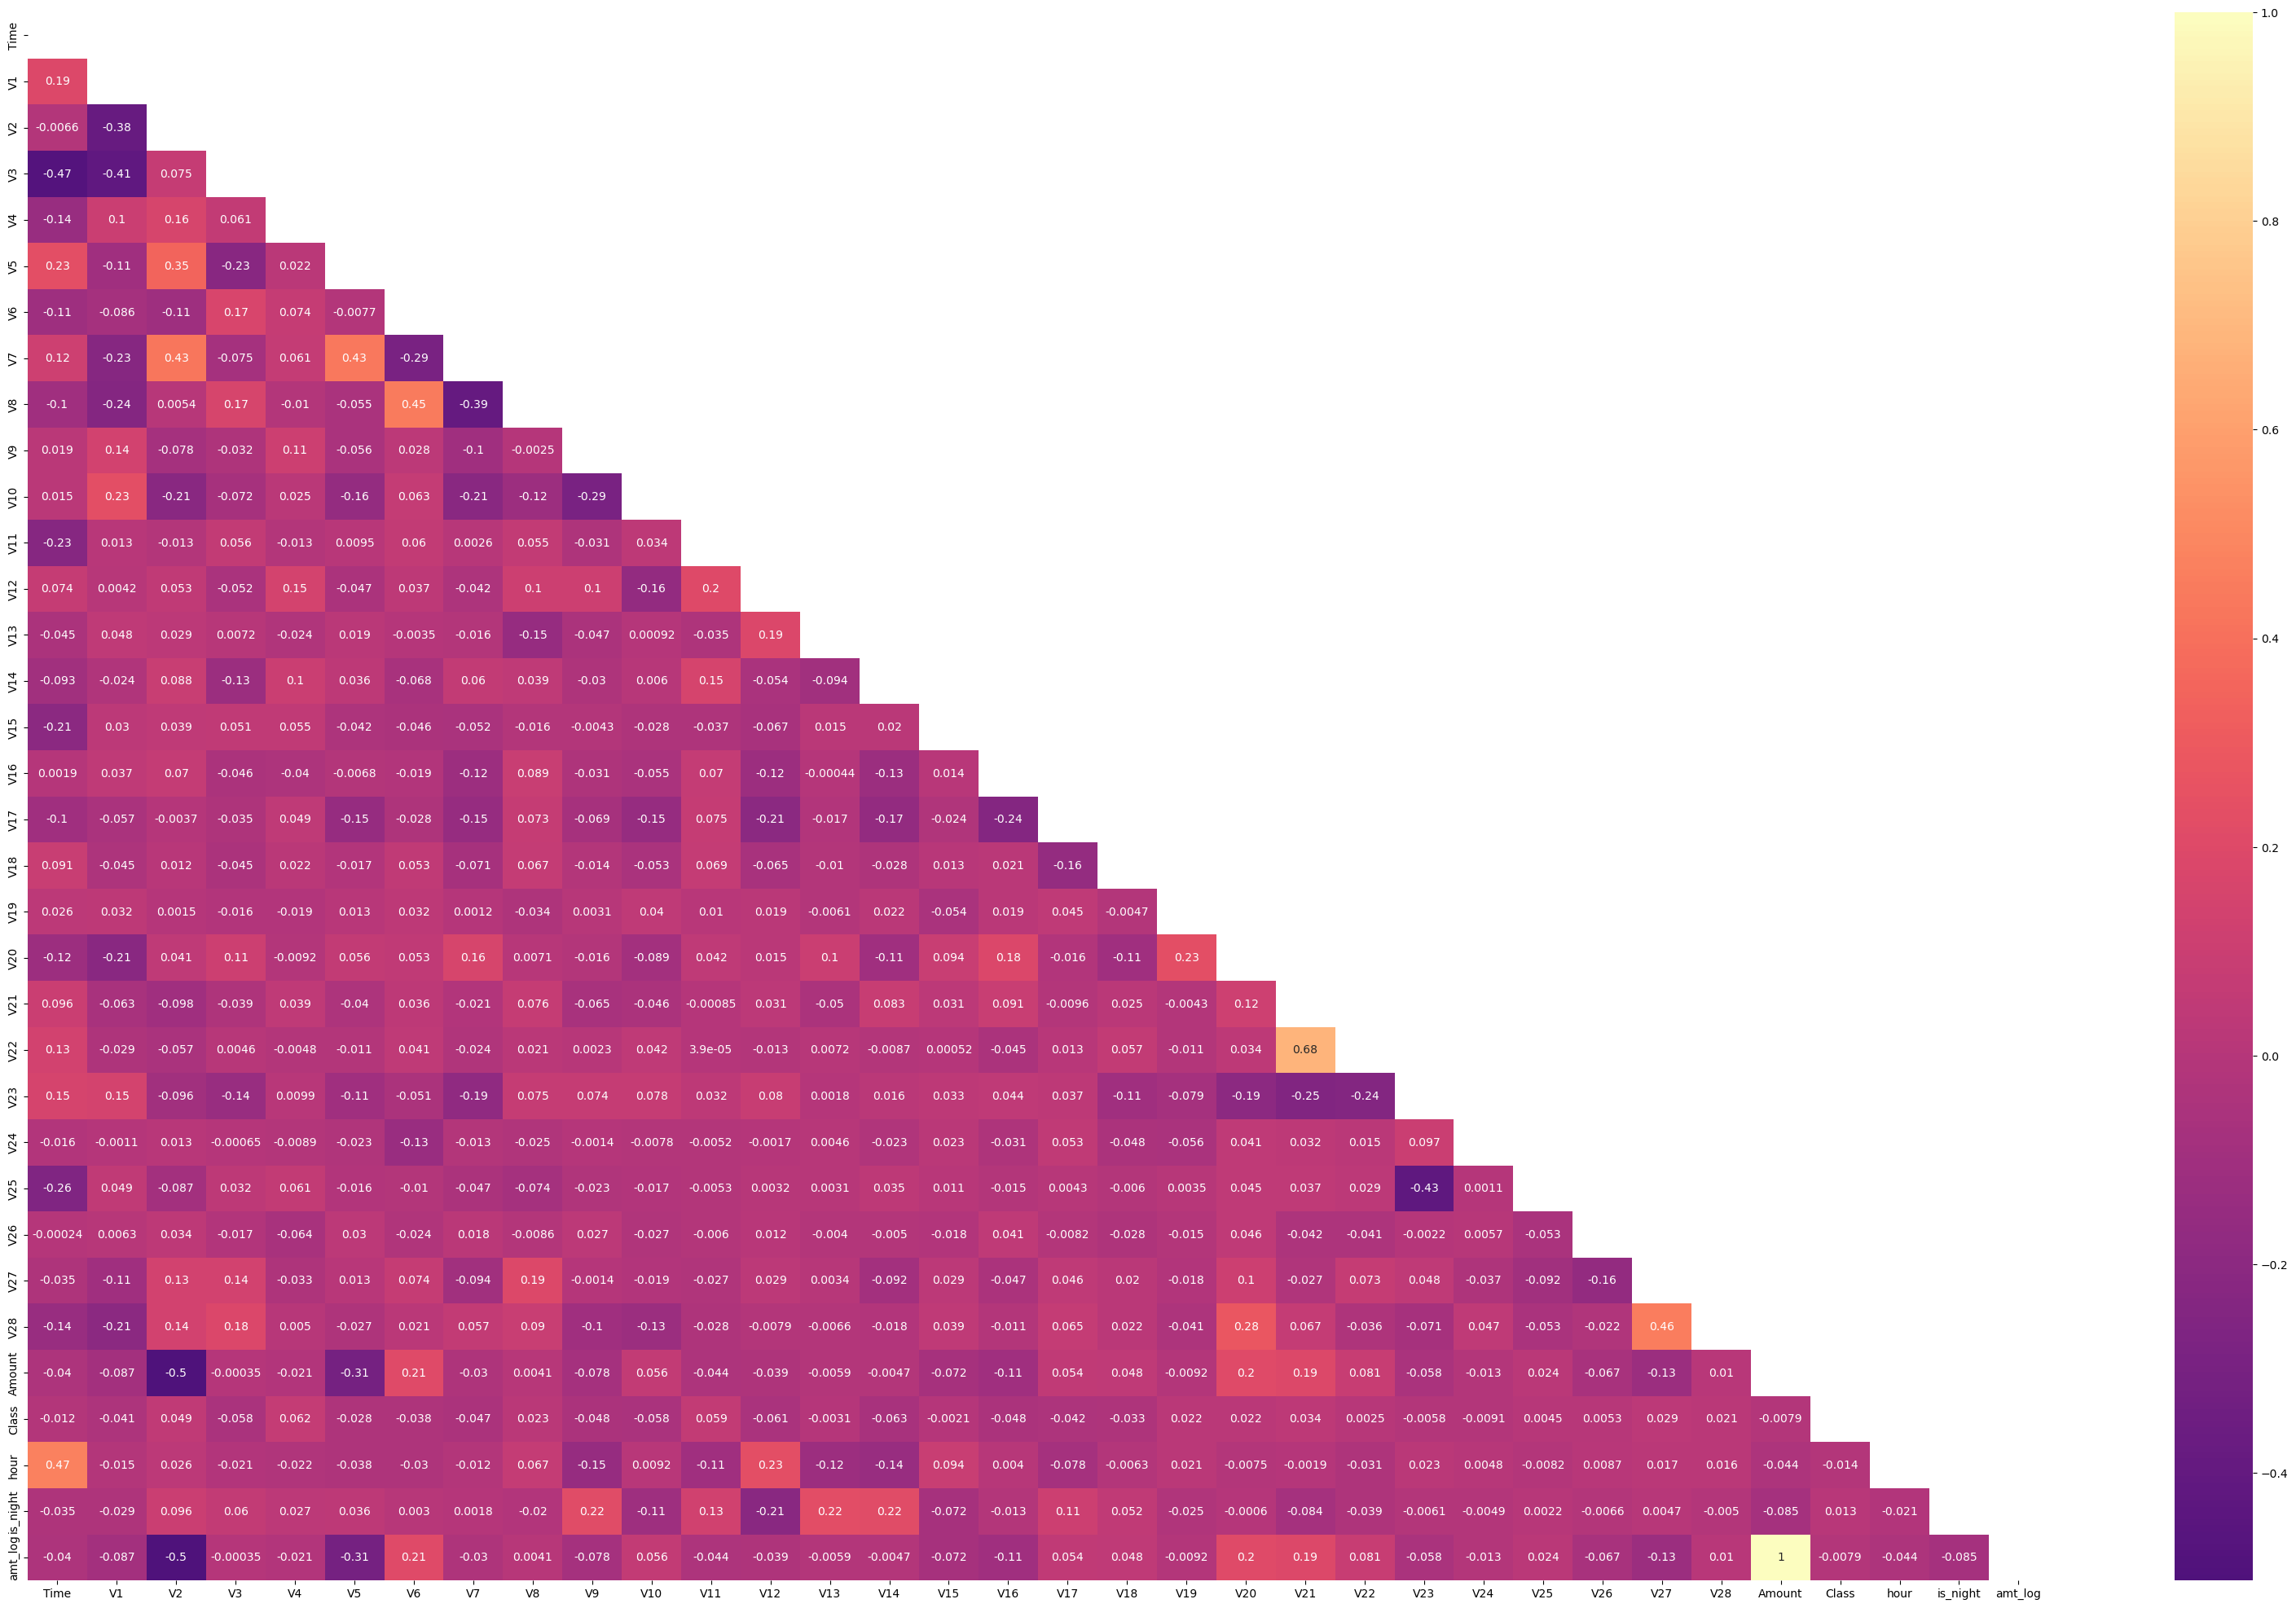

In [21]:

mask = np.triu(np.ones_like(spearman_corr, dtype=bool))
plt.figure(figsize=(40,25))
sns.heatmap(
    spearman_corr,
    mask=mask,
    annot=True,
    cmap='magma',
    center=0
)

In [22]:
corr_target = (
    df.corr(numeric_only=True)['Class']
      .drop('Class')
      .sort_values(key=abs, ascending=False)
)

corr_target

V17        -0.313498
V14        -0.293375
V12        -0.250711
V10        -0.206971
V16        -0.187186
V3         -0.182322
V7         -0.172347
V11         0.149067
V4          0.129326
V18        -0.105340
V1         -0.094486
V9         -0.094021
V5         -0.087812
V2          0.084624
V6         -0.043915
V19         0.033631
V8          0.033068
V21         0.026357
V27         0.021892
V20         0.021486
hour       -0.016740
is_night    0.013115
Time       -0.012359
V28         0.009682
amt_log    -0.007798
V24        -0.007210
V23        -0.006333
Amount      0.005777
V22         0.004887
V26         0.004265
V13        -0.003897
V15        -0.003300
V25         0.003202
Name: Class, dtype: float64

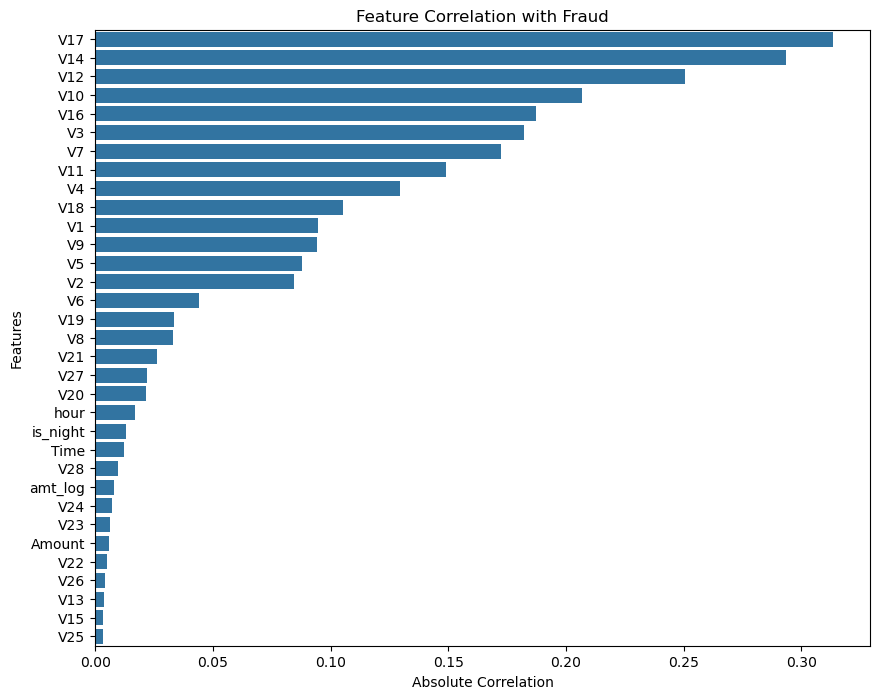

In [23]:
corr_df = pd.DataFrame({
    'Feature': corr_target.index,
    'Correlation': corr_target.values,
    'Abs_Correlation': abs(corr_target.values)
})

plt.figure(figsize=(10,8))

sns.barplot(
    data=corr_df,
    x='Abs_Correlation',
    y='Feature'
)

plt.title('Feature Correlation with Fraud')
plt.xlabel('Absolute Correlation')
plt.ylabel('Features')

plt.show()

## Splitting the Dataset into train(80%) and test(20%) sets

In [24]:
from sklearn.model_selection import train_test_split

X = df.drop("Class", axis=1)
y = df["Class"]

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [25]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(226980, 33)
(226980,)
(56746, 33)
(56746,)


Total features    : 33
Features kept     : 17
Features dropped  : 16

Selected features :
V17    0.320670
V14    0.301644
V12    0.254684
V10    0.211641
V16    0.190323
V3     0.188869
V7     0.180981
V11    0.152115
V4     0.129719
V18    0.107100
V1     0.097596
V9     0.095726
V5     0.091958
V2     0.087484
V6     0.044739
V8     0.035046
V19    0.034790
Name: Class, dtype: float64


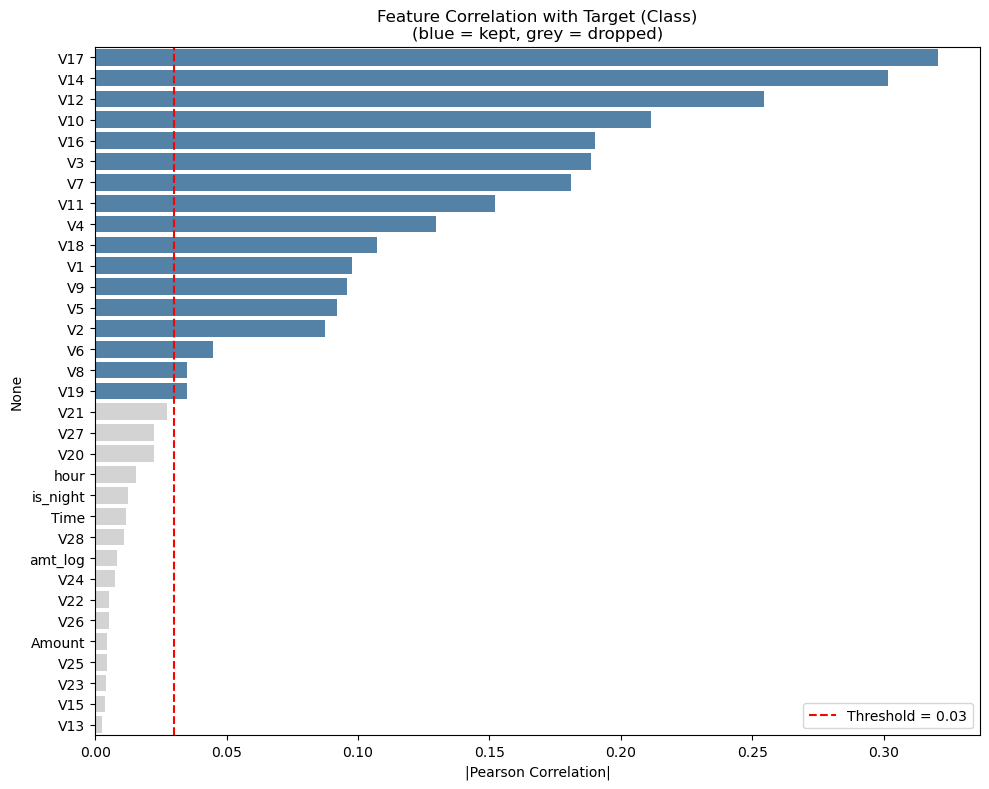

In [26]:
train_df = pd.DataFrame(x_train, columns=X.columns)
train_df['Class'] = y_train.values

corr_with_target = train_df.corr()['Class'].drop('Class')
corr_abs = corr_with_target.abs().sort_values(ascending=False)

THRESHOLD = 0.03
selected_features = corr_abs[corr_abs > THRESHOLD].index.tolist()

print(f"Total features    : {x_train.shape[1]}")
print(f"Features kept     : {len(selected_features)}")
print(f"Features dropped  : {x_train.shape[1] - len(selected_features)}")
print(f"\nSelected features :\n{corr_abs[corr_abs > THRESHOLD]}")


plt.figure(figsize=(10, 8))
colors = ['steelblue' if f in selected_features else 'lightgray' for f in corr_abs.index]
sns.barplot(x=corr_abs.values, y=corr_abs.index, palette=colors)
plt.axvline(x=THRESHOLD, color='red', linestyle='--', label=f'Threshold = {THRESHOLD}')
plt.title('Feature Correlation with Target (Class)\n(blue = kept, grey = dropped)')
plt.xlabel('|Pearson Correlation|')
plt.tight_layout()
plt.legend()
plt.show()

In [27]:

scaler = StandardScaler()
x_train_scaled_full = scaler.fit_transform(x_train)
x_test_scaled_full  = scaler.transform(x_test)


feature_idx = [x_train.columns.get_loc(f) for f in selected_features]
x_train_scaled = x_train_scaled_full[:, feature_idx]
x_test_scaled  = x_test_scaled_full[:, feature_idx]

print(f"x_train_scaled shape: {x_train_scaled.shape}")
print(f"x_test_scaled  shape: {x_test_scaled.shape}")

x_train_scaled shape: (226980, 17)
x_test_scaled  shape: (56746, 17)


## Applying SMOTE technique to Handle class Imbalance

In [28]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy=0.2,random_state=42)

x_train_resampled, y_train_resampled = smote.fit_resample(x_train_scaled,y_train)

In [29]:
print(x_train_resampled.shape)
print(y_train_resampled.shape)

(271922, 17)
(271922,)


## Applying CART Algorithm(SMOTE)

In [31]:
cart_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

# Train model
cart_model.fit(x_train_resampled, y_train_resampled)

# Predictions
cart_pred=cart_model.predict(x_test_scaled)

# Accuracy
cart_accuracy = accuracy_score(y_test, cart_pred)

print("\nCART Accuracy:")
print(cart_accuracy)

cart_precision=precision_score(y_test, cart_pred)
print("\nPrecision Score:")
print(cart_precision)

cart_f1=f1_score(y_test, cart_pred)
print("\nF1 Score:")
print(cart_f1)

cart_recall=recall_score(y_test, cart_pred)
print("\nRecall Score:")
print(cart_recall)

# Confusion Matrix
cart_confusion_matrix = confusion_matrix(y_test, cart_pred)
print("\nConfusion Matrix:")
print(cart_confusion_matrix)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, cart_pred))


CART Accuracy:
0.9967046135410426

Precision Score:
0.3050847457627119

F1 Score:
0.4350453172205438

Recall Score:
0.7578947368421053

Confusion Matrix:
[[56487   164]
 [   23    72]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.31      0.76      0.44        95

    accuracy                           1.00     56746
   macro avg       0.65      0.88      0.72     56746
weighted avg       1.00      1.00      1.00     56746



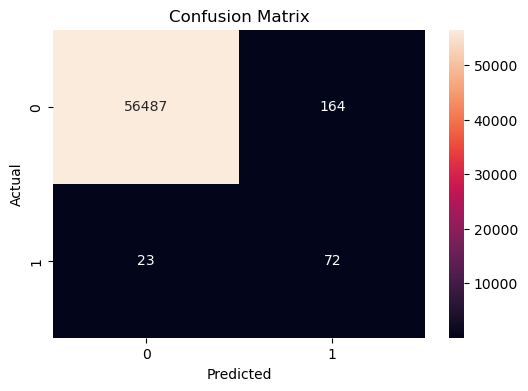

In [32]:
plt.figure(figsize=(6,4))
sns.heatmap(cart_confusion_matrix, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

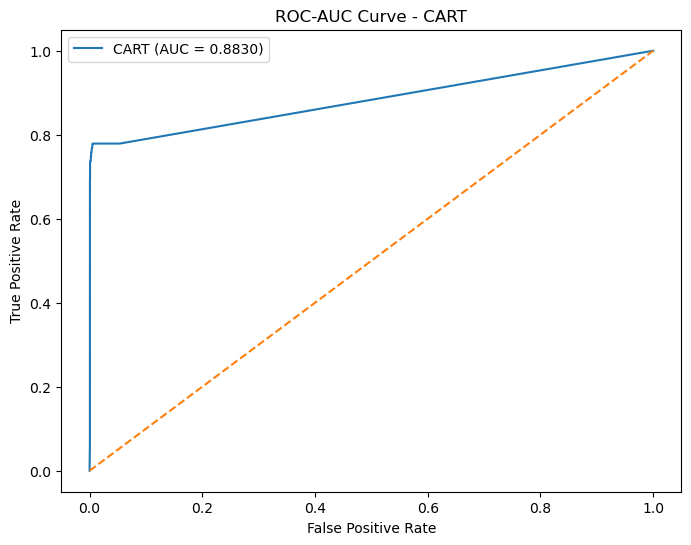

In [33]:

# ROC Curve
cart_prob = cart_model.predict_proba(
    x_test_scaled
)[:,1]
cart_fpr, cart_tpr, _ = roc_curve(
    y_test,
    cart_prob
)

# AUC Score
cart_auc = roc_auc_score(
    y_test,
    cart_prob
)

# Plot
plt.figure(figsize=(8,6))

plt.plot(
    cart_fpr,
    cart_tpr,
    label=f'CART (AUC = {cart_auc:.4f})'
)

plt.plot(
    [0,1],
    [0,1],
    linestyle='--'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC-AUC Curve - CART')

plt.legend()

plt.show()

## Applying Random Forest(SMOTE)

In [34]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

# Train Model
rf_model.fit(x_train_resampled,y_train_resampled)

# Predictions
rf_pred = rf_model.predict(x_test_scaled)

rf_prob = rf_model.predict_proba(
    x_test_scaled
)[:,1]

# Accuracy
rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print("\nRandom Forest Accuracy:")
print(rf_accuracy)

# Precision
rf_precision = precision_score(y_test,rf_pred)

print("\nPrecision Score:")
print(rf_precision)

# Recall
rf_recall = recall_score(y_test,rf_pred)

print("\nRecall Score:")
print(rf_recall)

# F1 Score
rf_f1 = f1_score(y_test,rf_pred)

print("\nF1 Score:")
print(rf_f1)

# ROC-AUC
rf_auc = roc_auc_score(y_test,rf_prob)

print("\nROC-AUC Score:")
print(rf_auc)

# Confusion Matrix
rf_cm = confusion_matrix(y_test,rf_pred)

print("\nConfusion Matrix:")
print(rf_cm)

# Classification Report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        rf_pred
    )
)


Random Forest Accuracy:
0.9993127268882388

Precision Score:
0.7978723404255319

Recall Score:
0.7894736842105263

F1 Score:
0.7936507936507936

ROC-AUC Score:
0.977157183084983

Confusion Matrix:
[[56632    19]
 [   20    75]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.80      0.79      0.79        95

    accuracy                           1.00     56746
   macro avg       0.90      0.89      0.90     56746
weighted avg       1.00      1.00      1.00     56746



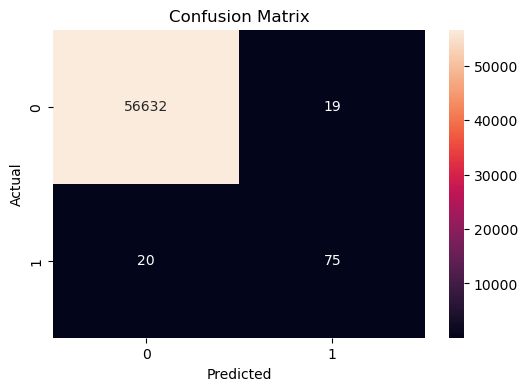

In [35]:
plt.figure(figsize=(6,4))
sns.heatmap(rf_cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

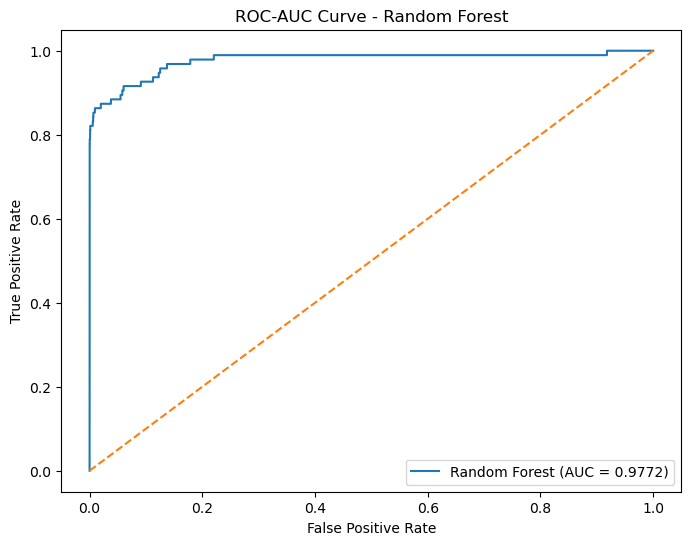

In [36]:
from sklearn.metrics import roc_curve, roc_auc_score

rf_prob = rf_model.predict_proba(
    x_test_scaled
)[:,1]

rf_fpr, rf_tpr, _ = roc_curve(y_test,rf_prob)

rf_auc = roc_auc_score(y_test,rf_prob)

plt.figure(figsize=(8,6))

plt.plot(rf_fpr,rf_tpr,label=f'Random Forest (AUC = {rf_auc:.4f})')

plt.plot([0,1],[0,1],linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC-AUC Curve - Random Forest')

plt.legend()

plt.show()

## Applying XGBoost Clssifier(SMOTE)

In [37]:

# XGBoost Model
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

# Train Model
xgb_model.fit(x_train_resampled,y_train_resampled)

# Predictions
xgb_pred = xgb_model.predict(x_test_scaled)

xgb_prob = xgb_model.predict_proba(x_test_scaled)[:,1]

# Accuracy
xgb_accuracy = accuracy_score(y_test,xgb_pred)

print("\nXGBoost Accuracy:")
print(xgb_accuracy)

# Precision
xgb_precision = precision_score(y_test,xgb_pred)

print("\nPrecision Score:")
print(xgb_precision)

# Recall
xgb_recall = recall_score(y_test,xgb_pred)

print("\nRecall Score:")
print(xgb_recall)

# F1 Score
xgb_f1 = f1_score(y_test,xgb_pred)

print("\nF1 Score:")
print(xgb_f1)

# ROC-AUC
xgb_auc = roc_auc_score(y_test,xgb_prob)

print("\nROC-AUC Score:")
print(xgb_auc)

# Confusion Matrix
xgb_cm = confusion_matrix(y_test,xgb_pred)

print("\nConfusion Matrix:")
print(xgb_cm)

# Classification Report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        xgb_pred
    )
)


XGBoost Accuracy:
0.998731188101364

Precision Score:
0.592

Recall Score:
0.7789473684210526

F1 Score:
0.6727272727272727

ROC-AUC Score:
0.9698987986461891

Confusion Matrix:
[[56600    51]
 [   21    74]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.59      0.78      0.67        95

    accuracy                           1.00     56746
   macro avg       0.80      0.89      0.84     56746
weighted avg       1.00      1.00      1.00     56746



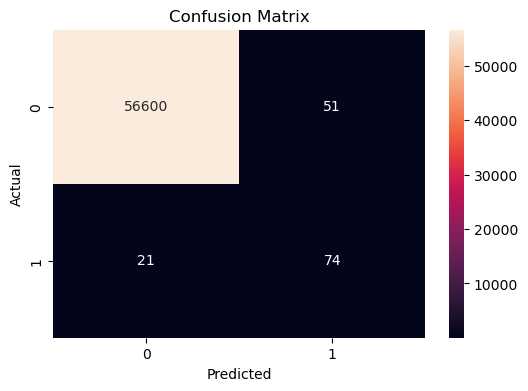

In [38]:
plt.figure(figsize=(6,4))
sns.heatmap(xgb_cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

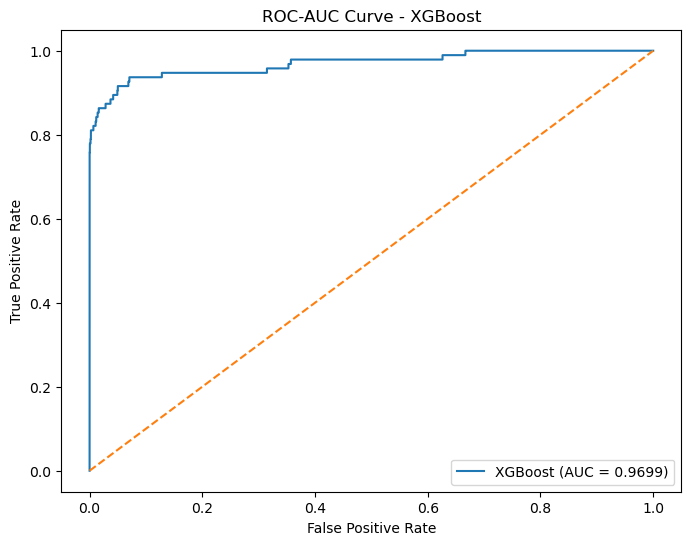

In [39]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probability Predictions
xgb_prob = xgb_model.predict_proba(x_test_scaled)[:,1]

# ROC Curve
xgb_fpr, xgb_tpr, _ = roc_curve(y_test,xgb_prob)

# AUC Score
xgb_auc = roc_auc_score(y_test,xgb_prob)

# Plot
plt.figure(figsize=(8,6))

plt.plot(xgb_fpr,xgb_tpr,label=f'XGBoost (AUC = {xgb_auc:.4f})')

plt.plot([0,1],[0,1],linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC-AUC Curve - XGBoost')

plt.legend()

plt.show()

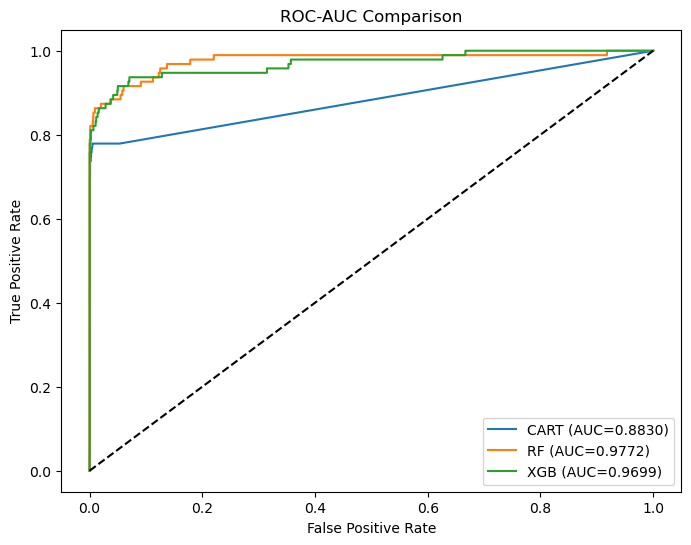

In [40]:
plt.figure(figsize=(8,6))

plt.plot(cart_fpr, cart_tpr,
         label=f'CART (AUC={cart_auc:.4f})')

plt.plot(rf_fpr, rf_tpr,
         label=f'RF (AUC={rf_auc:.4f})')

plt.plot(xgb_fpr, xgb_tpr,
         label=f'XGB (AUC={xgb_auc:.4f})')

plt.plot([0,1],[0,1],'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('ROC-AUC Comparison')

plt.legend()

plt.show()

## CART Model Evaluation (Imbalanced Data Handling via Class Weights, No SMOTE)

In [45]:
cart_model1 = DecisionTreeClassifier(
    criterion='gini',
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42
)

# Train model
cart_model1.fit(x_train_scaled, y_train)

# Predictions
cart_pred1=cart_model1.predict(x_test_scaled)

cart_prob1 = cart_model1.predict_proba(
    x_test_scaled
)[:,1]

# Accuracy
cart_accuracy1 = accuracy_score(y_test, cart_pred1)

print("\nCART Accuracy:")
print(cart_accuracy1)

cart_precision1=precision_score(y_test, cart_pred1)
print("\nPrecision Score:")
print(cart_precision1)

cart1_f1=f1_score(y_test, cart_pred1)
print("\nF1 Score:")
print(cart1_f1)

cart1_recall=recall_score(y_test, cart_pred1)
print("\nRecall Score:")
print(cart1_recall)

cart_auc1 = roc_auc_score(y_test,cart_prob1)
print('\n AUC:')
print(cart_auc1)
# Confusion Matrix
cart_confusion_matrix1 = confusion_matrix(y_test, cart_pred1)
print("\nConfusion Matrix:")
print(cart_confusion_matrix1)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, cart_pred1))


CART Accuracy:
0.9973742642653227

Precision Score:
0.365

F1 Score:
0.49491525423728816

Recall Score:
0.7684210526315789

 AUC:
0.8838630618310264

Confusion Matrix:
[[56524   127]
 [   22    73]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.36      0.77      0.49        95

    accuracy                           1.00     56746
   macro avg       0.68      0.88      0.75     56746
weighted avg       1.00      1.00      1.00     56746



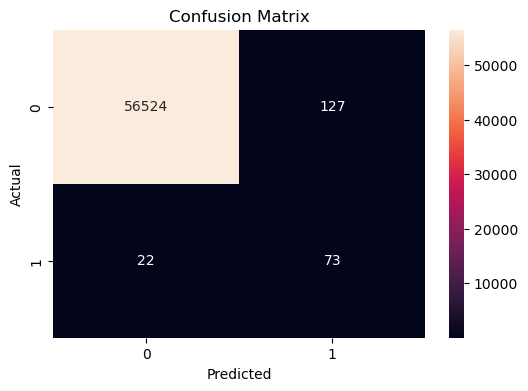

In [46]:
plt.figure(figsize=(6,4))
sns.heatmap(cart_confusion_matrix1, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Random Forest Model Evaluation (Imbalanced Data Handling via Class Weights, No SMOTE)

In [47]:
rf_model1 = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)

# Train Model
rf_model1.fit(x_train_scaled,y_train)

# Predictions
rf_pred1 = rf_model1.predict(x_test_scaled)

rf_prob1 = rf_model1.predict_proba(
    x_test_scaled
)[:,1]

# Accuracy
rf_accuracy1 = accuracy_score(
    y_test,
    rf_pred1
)

print("\nRandom Forest Accuracy:")
print(rf_accuracy1)

# Precision
rf_precision1 = precision_score(y_test,rf_pred1)

print("\nPrecision Score:")
print(rf_precision1)

# Recall
rf_recall_1 = recall_score(y_test,rf_pred1)

print("\nRecall Score:")
print(rf_recall_1)

# F1 Score
rf_f1_1 = f1_score(y_test,rf_pred1)

print("\nF1 Score:")
print(rf_f1_1)

# ROC-AUC
rf_auc1 = roc_auc_score(y_test,rf_prob1)

print("\nROC-AUC Score:")
print(rf_auc1)

# Confusion Matrix
rf_cm1 = confusion_matrix(y_test,rf_pred1)

print("\nConfusion Matrix:")
print(rf_cm1)

# Classification Report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        rf_pred1
    )
)


Random Forest Accuracy:
0.9994008388256441

Precision Score:
0.8860759493670886

Recall Score:
0.7368421052631579

F1 Score:
0.8045977011494253

ROC-AUC Score:
0.9408411985109196

Confusion Matrix:
[[56642     9]
 [   25    70]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.89      0.74      0.80        95

    accuracy                           1.00     56746
   macro avg       0.94      0.87      0.90     56746
weighted avg       1.00      1.00      1.00     56746



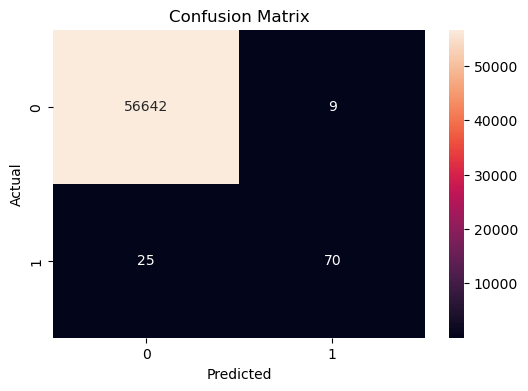

In [48]:
plt.figure(figsize=(6,4))
sns.heatmap(rf_cm1, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## XGBoost Model Evaluation (Imbalanced Data Handling via Class Weights, No SMOTE)

In [49]:
from xgboost import XGBClassifier

# XGBoost Model
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

xgb_model1 = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=neg/pos,
    random_state=42,
    eval_metric='logloss'
)

# Train Model
xgb_model1.fit(x_train_scaled,y_train)

# Predictions
xgb_pred1 = xgb_model1.predict(x_test_scaled)

xgb_prob1 = xgb_model1.predict_proba(x_test_scaled)[:,1]

# Accuracy
xgb_accuracy1 = accuracy_score(y_test,xgb_pred1)

print("\nXGBoost Accuracy:")
print(xgb_accuracy1)

# Precision
xgb_precision1 = precision_score(y_test,xgb_pred1)

print("\nPrecision Score:")
print(xgb_precision1)

# Recall
xgb_recall1 = recall_score(y_test,xgb_pred1)

print("\nRecall Score:")
print(xgb_recall1)

# F1 Score
xgb1_f1 = f1_score(y_test,xgb_pred1)

print("\nF1 Score:")
print(xgb1_f1)

# ROC-AUC
xgb_auc1 = roc_auc_score(y_test,xgb_prob1)

print("\nROC-AUC Score:")
print(xgb_auc1)

# Confusion Matrix
xgb_cm1 = confusion_matrix(y_test,xgb_pred1)

print("\nConfusion Matrix:")
print(xgb_cm1)

# Classification Report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        xgb_pred1
    )
)


XGBoost Accuracy:
0.9993303492757198

Precision Score:
0.8202247191011236

Recall Score:
0.7684210526315789

F1 Score:
0.7934782608695652

ROC-AUC Score:
0.9689651039745663

Confusion Matrix:
[[56635    16]
 [   22    73]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.82      0.77      0.79        95

    accuracy                           1.00     56746
   macro avg       0.91      0.88      0.90     56746
weighted avg       1.00      1.00      1.00     56746



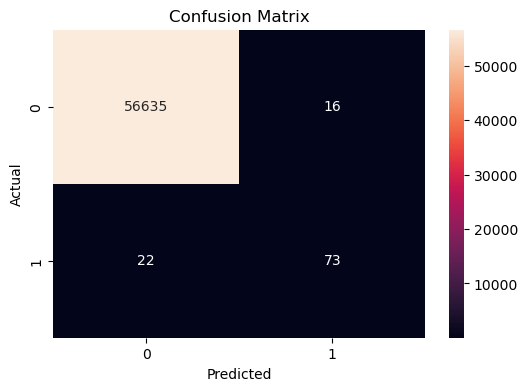

In [50]:
plt.figure(figsize=(6,4))
sns.heatmap(xgb_cm1, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Implementing Explainable AI(XAI) -- SHAP and LIME

In [54]:
%pip install shap lime

Note: you may need to restart the kernel to use updated packages.


In [55]:
import shap
import lime
import lime.lime_tabular

shap.initjs()

In [56]:
np.random.seed(42)
idx = np.random.choice(x_test_scaled.shape[0], 200, replace=False)


fraud_idx    = np.where(y_test == 1)[0][0]

X_sample     = x_test_scaled[idx]              
X_fraud      = x_test_scaled[[fraud_idx]]    


X_sample_df  = pd.DataFrame(X_sample, columns=selected_features)
X_fraud_df   = pd.DataFrame(X_fraud,  columns=selected_features)

np.random.seed(42)
bg_idx        = np.random.choice(x_train_scaled.shape[0], 100, replace=False)
background    = x_train_scaled[bg_idx]          
background_df = pd.DataFrame(background, columns=selected_features)

print('X_sample shape    :', X_sample.shape)
print('X_fraud shape     :', X_fraud.shape)
print('background shape  :', background.shape)

X_sample shape    : (200, 17)
X_fraud shape     : (1, 17)
background shape  : (100, 17)


### SHAP — Random Forest
`TreeExplainer` on RF → 3D output → index `[:, :, 1]` for fraud class

In [57]:

rf_explainer = shap.TreeExplainer(rf_model)
rf_shap = rf_explainer(X_sample_df)  

print('RF SHAP values shape:', rf_shap.values.shape)

RF SHAP values shape: (200, 17, 2)


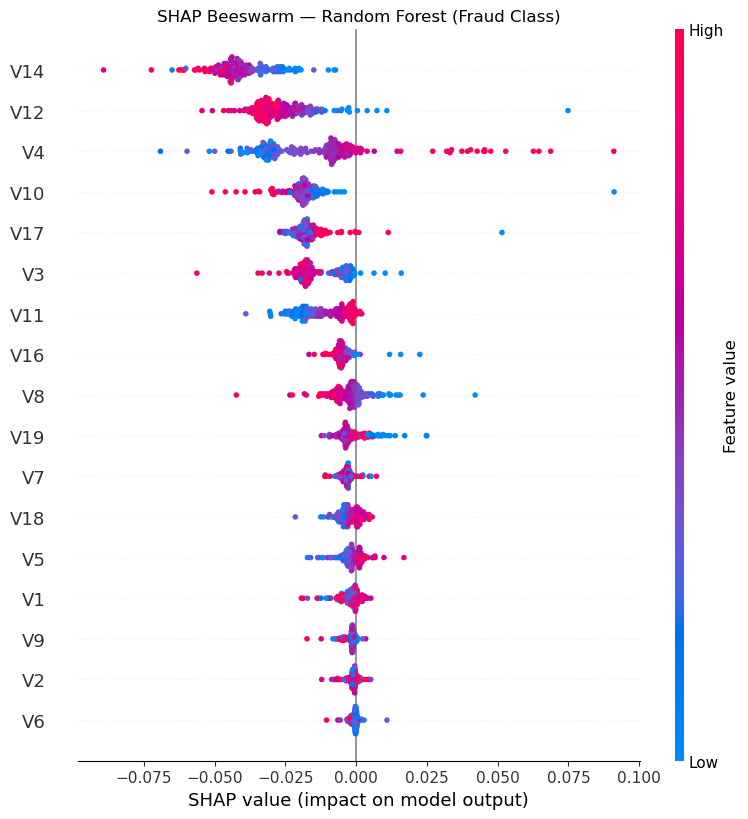

<Figure size 640x480 with 0 Axes>

In [58]:
# RF — Beeswarm
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(rf_shap[:, :, 1], max_display=17, show=False)
plt.title('SHAP Beeswarm — Random Forest (Fraud Class)')
plt.tight_layout()
plt.show()
plt.savefig("rf_shap.png", dpi=300, bbox_inches="tight")

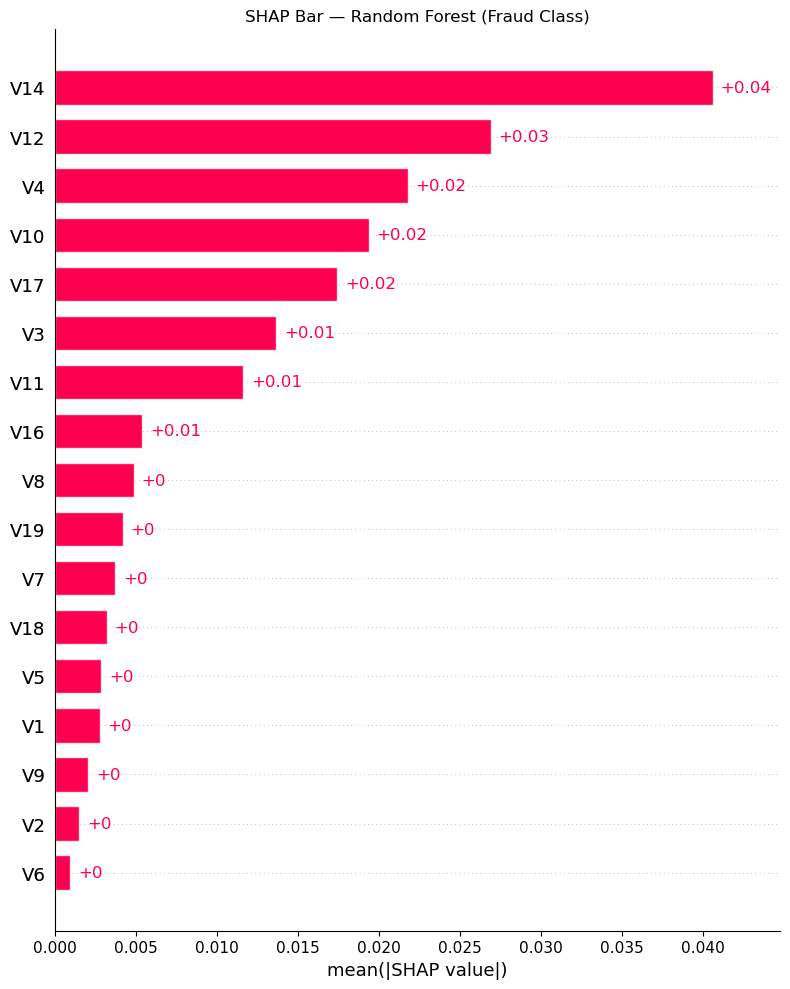

In [59]:
# RF — Bar
plt.figure(figsize=(10, 6))
shap.plots.bar(rf_shap[:, :, 1], max_display=17, show=False)
plt.title('SHAP Bar — Random Forest (Fraud Class)')
plt.tight_layout()
plt.show()

### SHAP — XGBoost
`TreeExplainer` on XGBoost binary classifier → 2D output → use directly (no `[:, :, 1]`)

In [60]:

xgb_explainer = shap.TreeExplainer(xgb_model)
xgb_shap = xgb_explainer(X_sample)  

print('XGBoost SHAP values shape:', xgb_shap.values.shape)

XGBoost SHAP values shape: (200, 17)


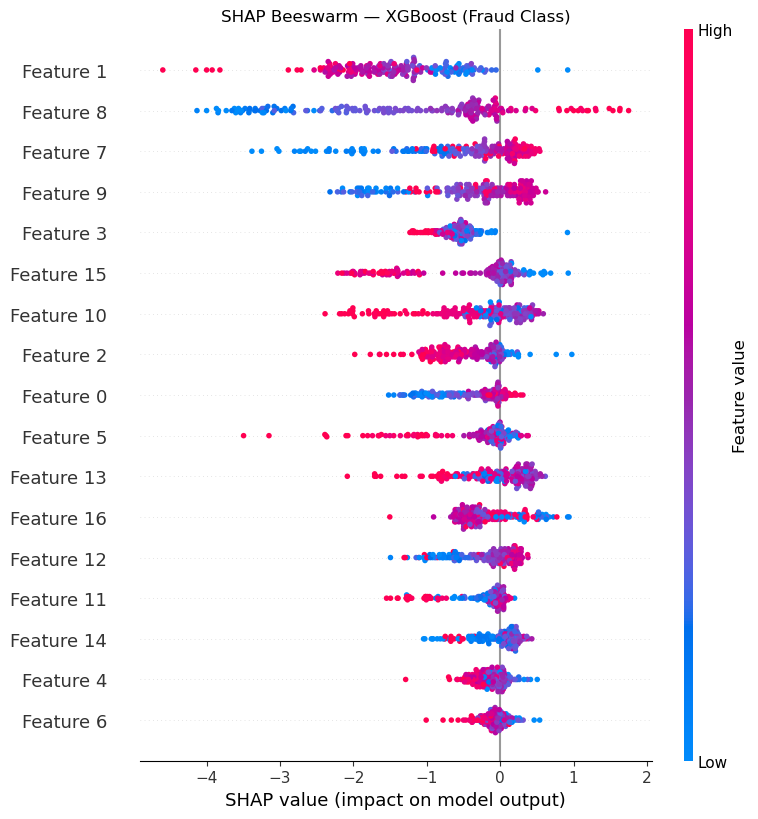

In [61]:

plt.figure(figsize=(10, 6))
shap.plots.beeswarm(
    xgb_shap,
    max_display=17,
    show=False
)
plt.title('SHAP Beeswarm — XGBoost (Fraud Class)')
plt.tight_layout()
plt.show()

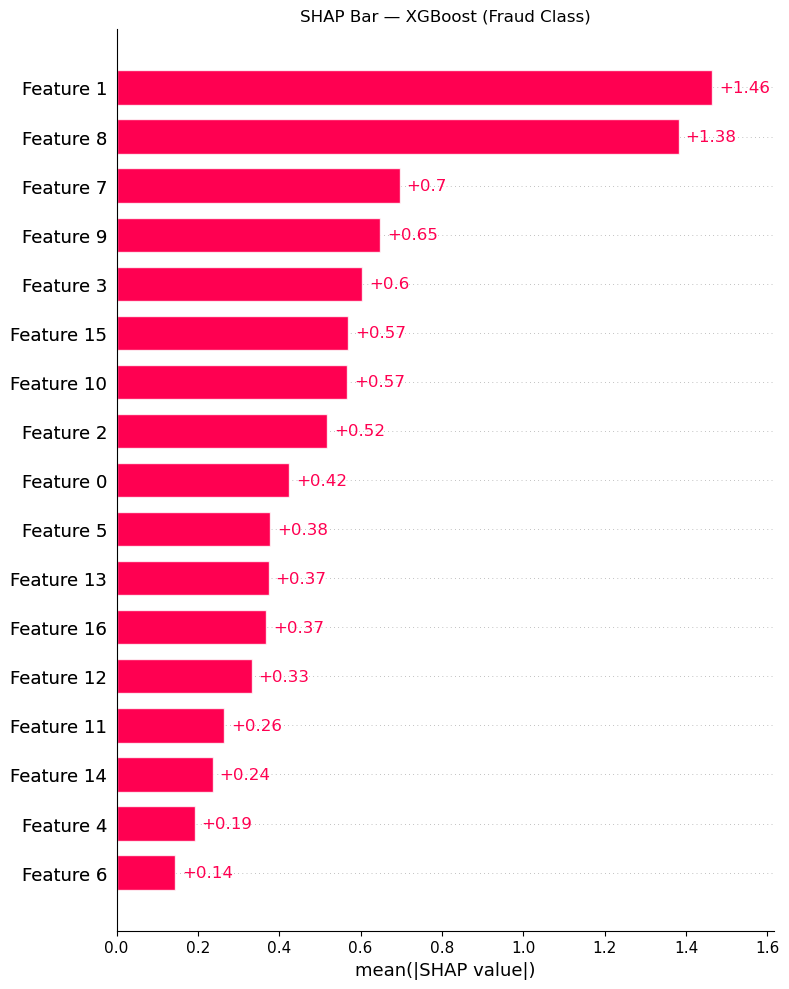

In [62]:
# XGBoost — Bar
plt.figure(figsize=(10, 6))
shap.plots.bar(xgb_shap, max_display=17, show=False)
plt.title('SHAP Bar — XGBoost (Fraud Class)')
plt.tight_layout()
plt.show()

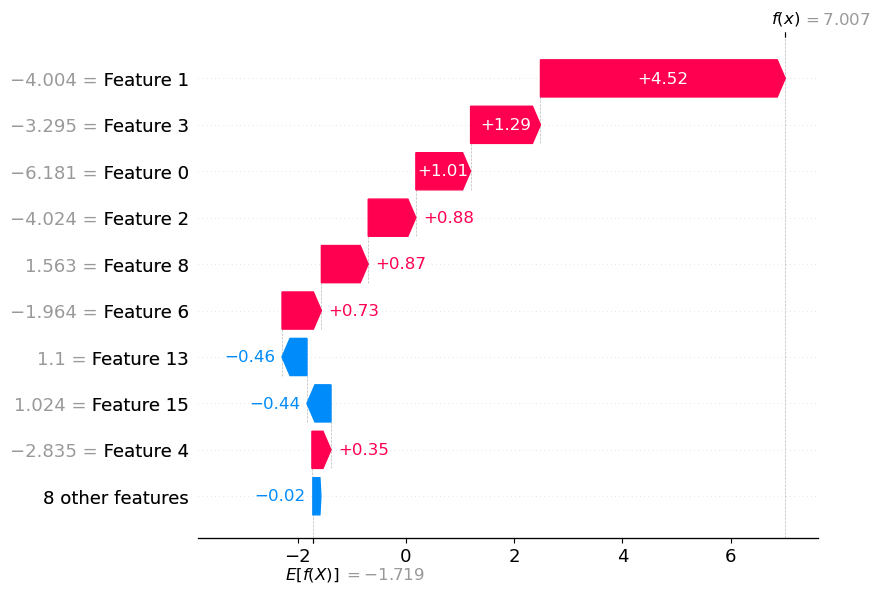

In [63]:

xgb_fraud_shap = xgb_explainer(X_fraud)  
shap.plots.waterfall(xgb_fraud_shap[0])

### SHAP — CART (Decision Tree)
`TreeExplainer` on CART → 3D output → index `[:, :, 1]`

> **Note:** `shap.Explainer` (not `TreeExplainer`) is used for the waterfall to allow a proper background dataset.

In [64]:

cart_explainer = shap.TreeExplainer(cart_model)
cart_shap_raw  = cart_explainer.shap_values(X_sample)

if isinstance(cart_shap_raw, list):
    cart_shap_fraud = cart_shap_raw[1]
else:
    cart_shap_fraud = cart_shap_raw

print('CART SHAP values shape:', cart_shap_fraud.shape)  

CART SHAP values shape: (200, 17, 2)


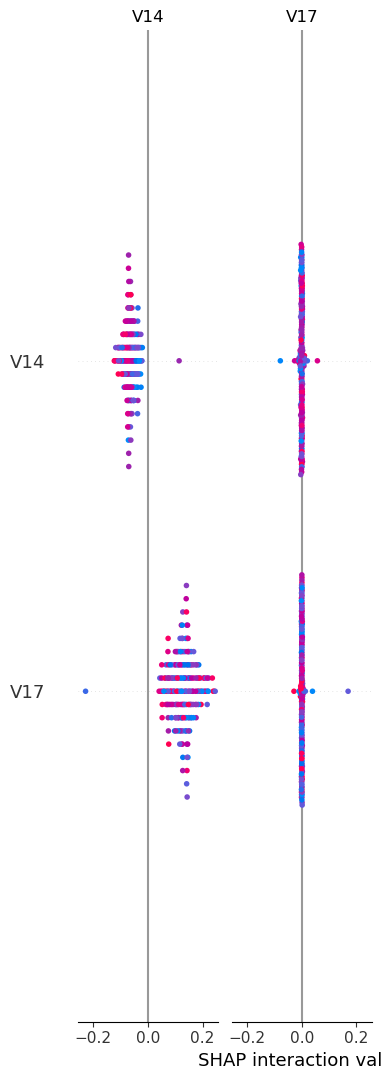

In [65]:
# CART — Summary/Beeswarm
shap.summary_plot(
    cart_shap_fraud,
    X_sample,
    feature_names=selected_features,
    max_display=12
)

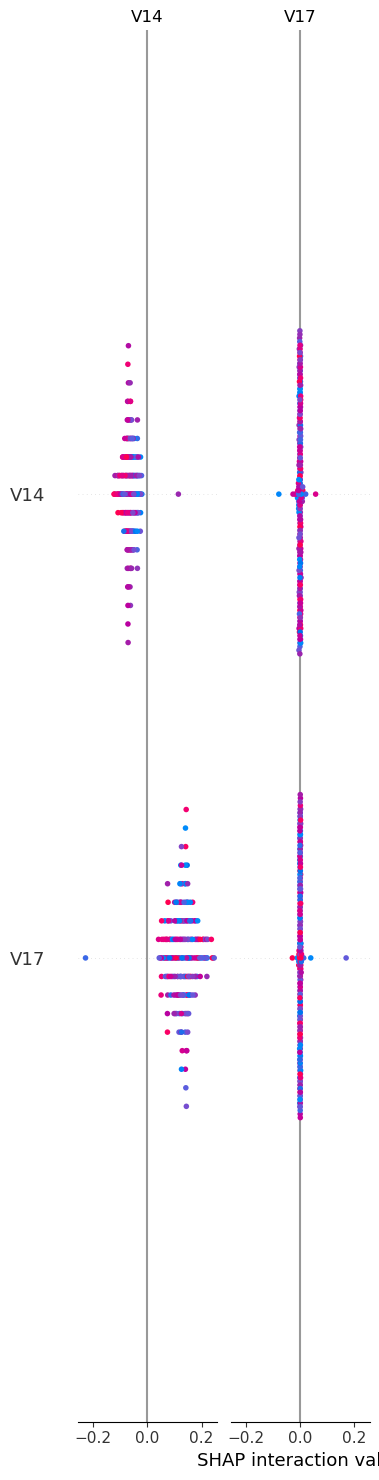

In [66]:
# CART — Bar
shap.summary_plot(
    cart_shap_fraud,
    X_sample,
    feature_names=selected_features,
    plot_type='bar',
    max_display=17
)

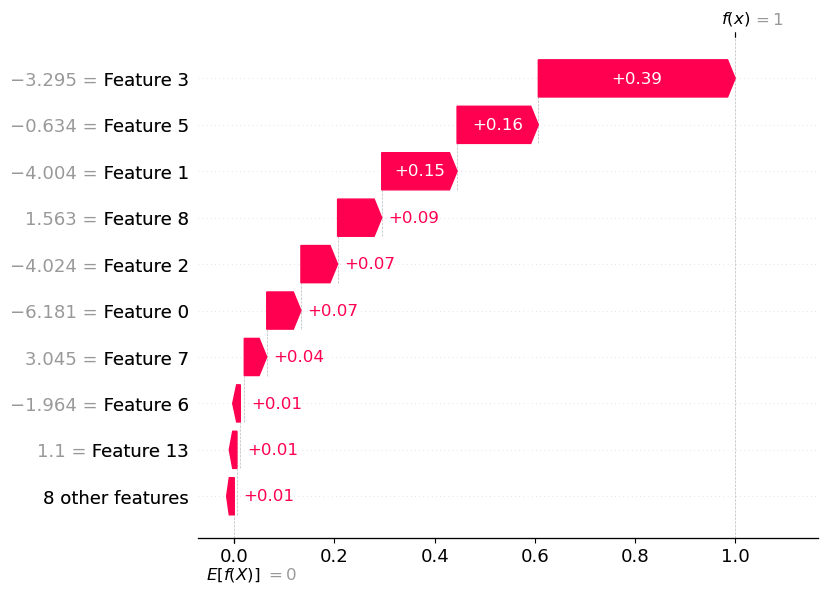

In [67]:
# CART — Waterfall for a fraud transaction
cart_explainer2 = shap.Explainer(cart_model, background)
cart_fraud_shap = cart_explainer2(X_fraud)

if cart_fraud_shap.values.ndim == 3:
    shap.plots.waterfall(cart_fraud_shap[0, :, 1])
else:
    shap.plots.waterfall(cart_fraud_shap[0])

### LIME — Local Explanations
One shared `LimeTabularExplainer` is created and reused for all three models.
All explanations are for a **fraud transaction** (consistent with fraud detection goal).

In [68]:
from lime.lime_tabular import LimeTabularExplainer


lime_explainer = LimeTabularExplainer(
    training_data=x_train_scaled,
    feature_names=selected_features,
    class_names=['Non-Fraud', 'Fraud'],
    mode='classification'
)

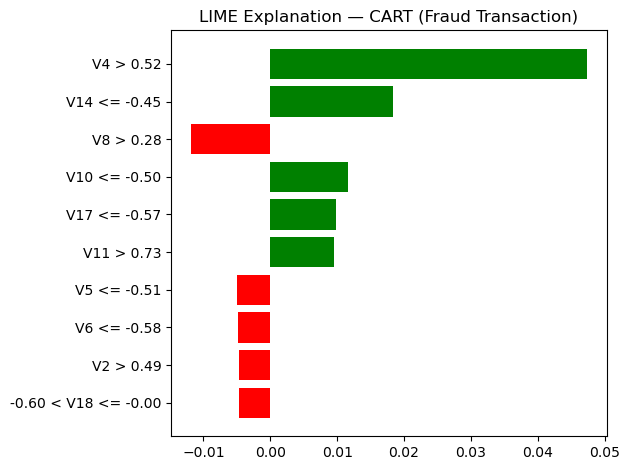

In [69]:

exp_cart = lime_explainer.explain_instance(
    data_row=X_fraud[0],   
    predict_fn=cart_model.predict_proba,
    num_features=10
)
fig = exp_cart.as_pyplot_figure()
plt.title('LIME Explanation — CART (Fraud Transaction)')
plt.tight_layout()
plt.show()

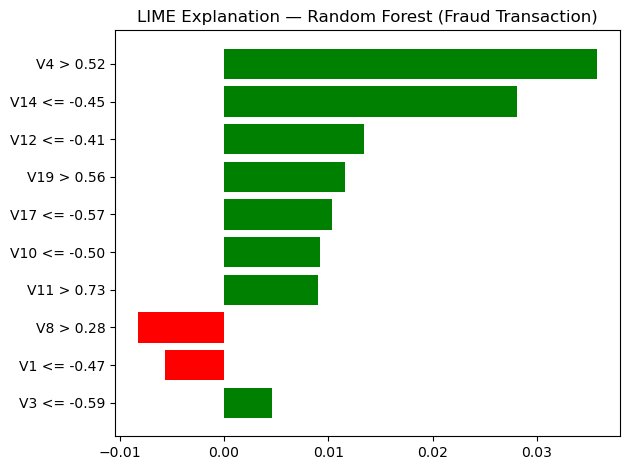

In [70]:
exp_rf = lime_explainer.explain_instance(
    data_row=X_fraud[0],   
    predict_fn=rf_model.predict_proba,
    num_features=10
)
fig = exp_rf.as_pyplot_figure()
plt.title('LIME Explanation — Random Forest (Fraud Transaction)')
plt.tight_layout()
plt.show()

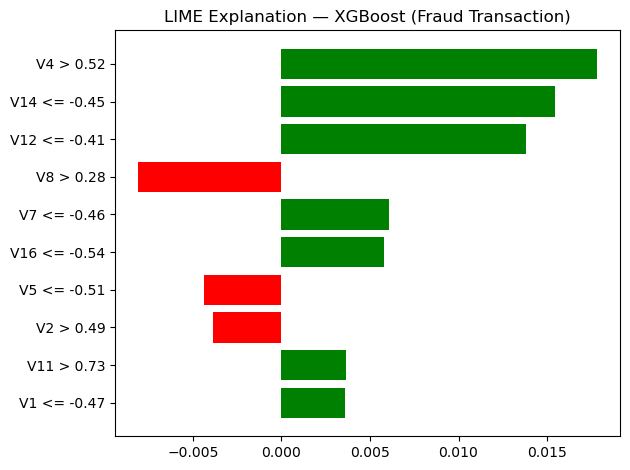

In [71]:
exp_xgb = lime_explainer.explain_instance(
    data_row=X_fraud[0],  
    predict_fn=xgb_model.predict_proba,
    num_features=10
)
fig = exp_xgb.as_pyplot_figure()
plt.title('LIME Explanation — XGBoost (Fraud Transaction)')
plt.tight_layout()
plt.show()

In [72]:
import joblib

joblib.dump(cart_model, "cart_model.pkl")
joblib.dump(rf_model, "rf_model.pkl")
joblib.dump(xgb_model, "xgb_model.pkl")

joblib.dump(scaler, "scaler.pkl")
joblib.dump(selected_features, "selected_features.pkl")

print("Models saved successfully!")

Models saved successfully!


In [73]:
import os
print(os.listdir())

['.anaconda', '.conda', '.continuum', '.eclipse', '.ipynb_checkpoints', '.ipython', '.jupyter', '.keras', '.local', '.matplotlib', '.qnx', '.streamlit', '.vscode', '.vscode-shared', 'AIML Dataset.csv', 'all_tickets_processed_improved_v3.csv', 'anaconda3', 'app.py', 'AppData', 'Application Data', 'archive (4).zip', 'cart_model.pkl', 'cart_shap.png', 'Contacts', 'Cookies', 'creditcard.csv', 'customer_support_tickets.csv', 'daily_sales-Copy1.csv', 'daily_sales.csv', 'Documents', 'Downloads', 'eda_plots.png', 'Favorites', 'feature_selection.png', 'future_forecast.csv', 'holidays_events.csv', 'ide-8.0-workspace', 'index1.html', 'lime_cart.png', 'lime_rf.png', 'lime_xgboost.png', 'Links', 'Local Settings', 'MBF(WOFS)-Copy2.ipynb', 'MBF-Copy1.ipynb', 'MBF-Copy2.ipynb', 'MBF-Copy2__2_.ipynb', 'MBF.ipynb', 'MBF_Fixed (6).ipynb', 'Microsoft', 'missing_value_report.csv', 'ML01.ipynb', 'ML_02.ipynb', 'ML_03.ipynb', 'model_comparison.png', 'monster_com-job_sample.csv', 'Music', 'My Documents', 'Net

In [74]:
import joblib

selected_features = joblib.load("selected_features.pkl")

print(selected_features)
print("\nTotal Features:", len(selected_features))

['V17', 'V14', 'V12', 'V10', 'V16', 'V3', 'V7', 'V11', 'V4', 'V18', 'V1', 'V9', 'V5', 'V2', 'V6', 'V8', 'V19']

Total Features: 17


## CART Model Evaluation (Imbalanced Data Handling Without Class Weights and SMOTE)

In [75]:
cart_model2 = DecisionTreeClassifier(
    criterion='gini',
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

# Train model
cart_model2.fit(x_train_scaled, y_train)

# Predictions
cart_pred2=cart_model2.predict(x_test_scaled)

cart_prob2 = cart_model1.predict_proba(
    x_test_scaled
)[:,1]

# Accuracy
cart_accuracy2 = accuracy_score(y_test, cart_pred2)

print("\nCART Accuracy:")
print(cart_accuracy2)

cart_precision2=precision_score(y_test, cart_pred2)
print("\nPrecision Score:")
print(cart_precision2)

cart2_f1=f1_score(y_test, cart_pred2)
print("\nF1 Score:")
print(cart2_f1)

cart2_recall=recall_score(y_test, cart_pred2)
print("\nRecall Score:")
print(cart2_recall)

cart_auc2 = roc_auc_score(y_test,cart_prob2)
print('\n AUC:')
print(cart_auc2)
# Confusion Matrix
cart_confusion_matrix2 = confusion_matrix(y_test, cart_pred2)
print("\nConfusion Matrix:")
print(cart_confusion_matrix2)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, cart_pred2))


CART Accuracy:
0.9993303492757198

Precision Score:
0.88

F1 Score:
0.7764705882352941

Recall Score:
0.6947368421052632

 AUC:
0.8838630618310264

Confusion Matrix:
[[56642     9]
 [   29    66]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.88      0.69      0.78        95

    accuracy                           1.00     56746
   macro avg       0.94      0.85      0.89     56746
weighted avg       1.00      1.00      1.00     56746



## Random Forest Model Evaluation (Imbalanced Data Handling Without Class Weights and SMOTE)

In [76]:
rf_model2 = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

# Train Model
rf_model2.fit(x_train_scaled,y_train)

# Predictions
rf_pred2 = rf_model2.predict(x_test_scaled)

rf_prob2 = rf_model2.predict_proba(
    x_test_scaled
)[:,1]

# Accuracy
rf_accuracy2 = accuracy_score(
    y_test,
    rf_pred2
)

print("\nRandom Forest Accuracy:")
print(rf_accuracy2)

# Precision
rf_precision2 = precision_score(y_test,rf_pred2)

print("\nPrecision Score:")
print(rf_precision2)

# Recall
rf_recall_2 = recall_score(y_test,rf_pred2)

print("\nRecall Score:")
print(rf_recall_2)

# F1 Score
rf_f1_2 = f1_score(y_test,rf_pred2)

print("\nF1 Score:")
print(rf_f1_2)

# ROC-AUC
rf_auc2 = roc_auc_score(y_test,rf_prob2)

print("\nROC-AUC Score:")
print(rf_auc2)

# Confusion Matrix
rf_cm2 = confusion_matrix(y_test,rf_pred2)

print("\nConfusion Matrix:")
print(rf_cm2)

# Classification Report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        rf_pred2
    )
)


Random Forest Accuracy:
0.9995241955380115

Precision Score:
0.9594594594594594

Recall Score:
0.7473684210526316

F1 Score:
0.8402366863905325

ROC-AUC Score:
0.9672408811476362

Confusion Matrix:
[[56648     3]
 [   24    71]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.96      0.75      0.84        95

    accuracy                           1.00     56746
   macro avg       0.98      0.87      0.92     56746
weighted avg       1.00      1.00      1.00     56746



## XGBoost Model Evaluation (Imbalanced Data Handling Without Class Weights and SMOTE)

In [77]:
xgb_model2 = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

# Train Model
xgb_model2.fit(x_train_scaled,y_train)

# Predictions
xgb_pred2 = xgb_model2.predict(x_test_scaled)

xgb_prob2 = xgb_model2.predict_proba(x_test_scaled)[:,1]

# Accuracy
xgb_accuracy2 = accuracy_score(y_test,xgb_pred2)

print("\nXGBoost Accuracy:")
print(xgb_accuracy2)

# Precision
xgb_precision2 = precision_score(y_test,xgb_pred2)

print("\nPrecision Score:")
print(xgb_precision2)

# Recall
xgb_recall2 = recall_score(y_test,xgb_pred2)

print("\nRecall Score:")
print(xgb_recall2)

# F1 Score
xgb2_f1 = f1_score(y_test,xgb_pred2)

print("\nF1 Score:")
print(xgb2_f1)

# ROC-AUC
xgb_auc2 = roc_auc_score(y_test,xgb_prob2)

print("\nROC-AUC Score:")
print(xgb_auc2)

# Confusion Matrix
xgb_cm2 = confusion_matrix(y_test,xgb_pred2)

print("\nConfusion Matrix:")
print(xgb_cm2)

# Classification Report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        xgb_pred2
    )
)


XGBoost Accuracy:
0.9994889507630493

Precision Score:
0.9583333333333334

Recall Score:
0.7263157894736842

F1 Score:
0.8263473053892215

ROC-AUC Score:
0.9697009111187707

Confusion Matrix:
[[56648     3]
 [   26    69]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.96      0.73      0.83        95

    accuracy                           1.00     56746
   macro avg       0.98      0.86      0.91     56746
weighted avg       1.00      1.00      1.00     56746



In [78]:
import pandas as pd

results = pd.DataFrame({

    'Model': ['CART','CART','CART',
              'RF','RF','RF',
              'XGB','XGB','XGB'],

    'Technique': ['Normal','Balanced','SMOTE',
                  'Normal','Balanced','SMOTE',
                  'Normal','Balanced','SMOTE'],

    'Accuracy': [0.999330,0.997374,0.996705,0.999524,0.999401,0.999313,0.999489,0.999330,0.998731],

    'Precision': [0.880,0.365,0.305,0.959,0.886,0.798,0.958,0.820,0.592],

    'Recall': [0.695,0.768,0.758,0.747,0.737,0.789,0.726,0.768,0.779],

    'F1': [0.776,0.495,0.435,0.840,0.805,0.794,0.826,0.793,0.673],

    'ROC_AUC': [0.884,0.884,0.884,0.967,0.941,0.977,0.970,0.969,0.970]})

results

,Model,Technique,Accuracy,Precision,Recall,F1,ROC_AUC
0,CART,Normal,0.999330,0.880,0.695,0.776,0.884
1,CART,Balanced,0.997374,0.365,0.768,0.495,0.884
2,CART,SMOTE,0.996705,0.305,0.758,0.435,0.884
3,RF,Normal,0.999524,0.959,0.747,0.840,0.967
4,RF,Balanced,0.999401,0.886,0.737,0.805,0.941
5,RF,SMOTE,0.999313,0.798,0.789,0.794,0.977
6,XGB,Normal,0.999489,0.958,0.726,0.826,0.970
7,XGB,Balanced,0.999330,0.820,0.768,0.793,0.969
8,XGB,SMOTE,0.998731,0.592,0.779,0.673,0.970


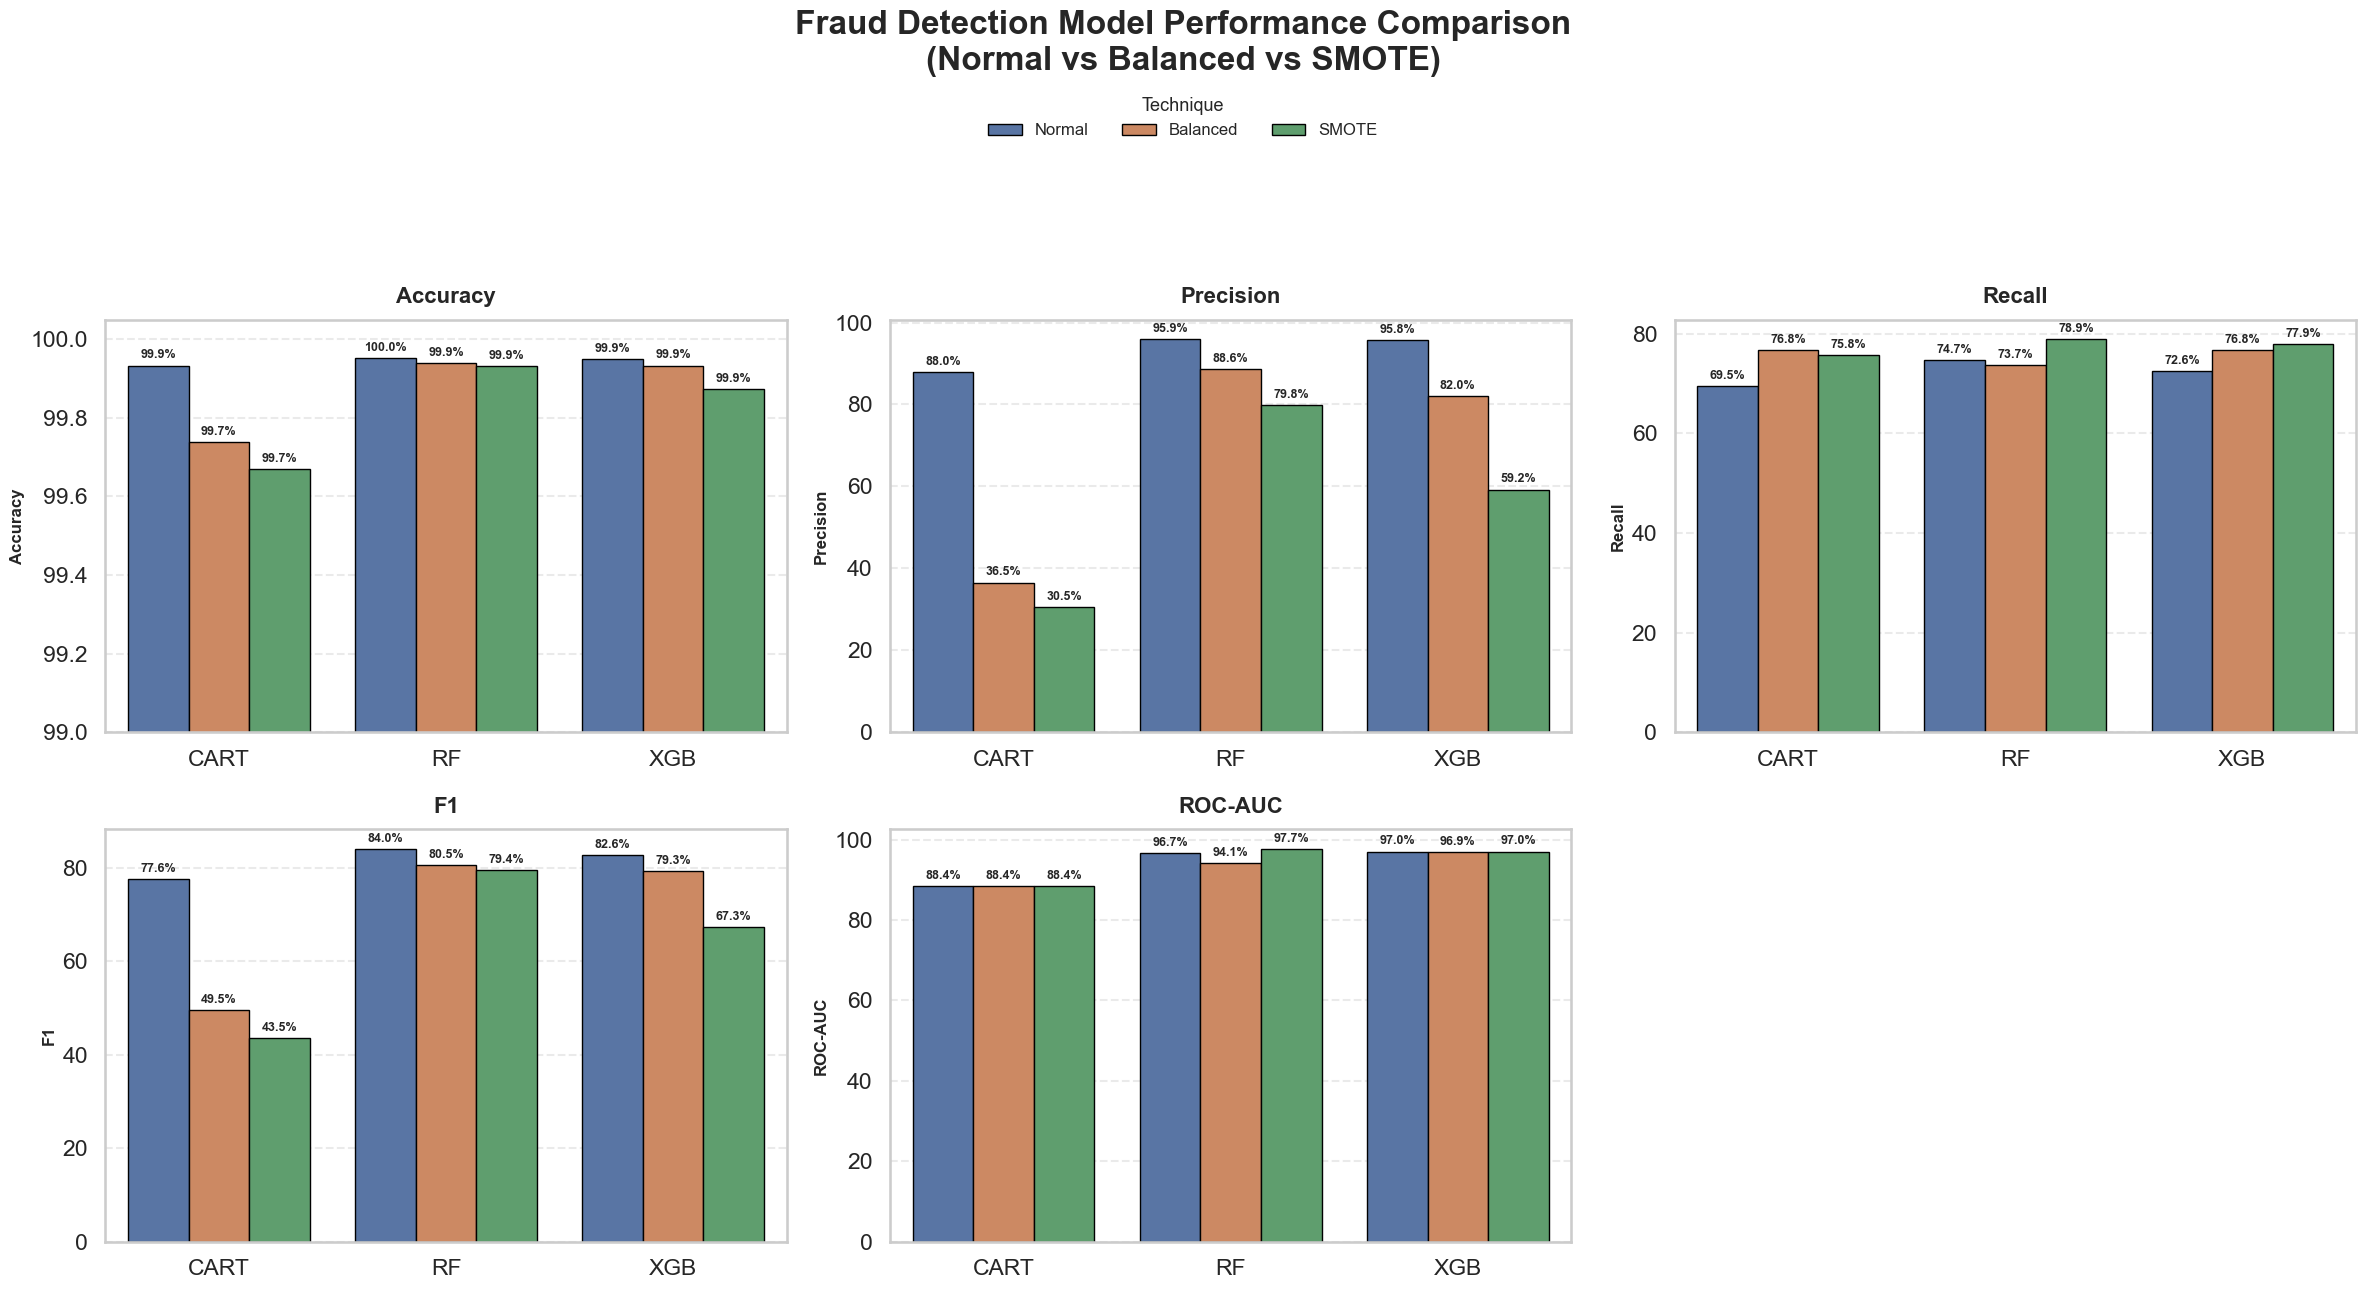

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns

results_plot = results.copy()


for col in ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']:
    results_plot[col] *= 100

sns.set_theme(style="whitegrid", context="talk")

metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']

fig, axes = plt.subplots(
    2, 3,
    figsize=(24, 12)
)

axes = axes.flatten()

palette = ['#4C72B0', '#DD8452', '#55A868']

for i, metric in enumerate(metrics):

    ax = axes[i]

    sns.barplot(
        data=results_plot,
        x='Model',
        y=metric,
        hue='Technique',
        palette=palette,
        edgecolor='black',
        linewidth=1,
        ax=ax
    )

    # Title
    ax.set_title(
        metric.replace('_', '-'),
        fontsize=16,
        fontweight='bold',
        pad=12
    )

    ax.set_xlabel('')
    ax.set_ylabel(
        metric.replace('_', '-'),
        fontsize=12,
        fontweight='bold'
    )

 
    ax.grid(
        axis='y',
        linestyle='--',
        alpha=0.4
    )

    for container in ax.containers:

        labels = ax.bar_label(
            container,
            fmt='%.1f%%',
            fontsize=9,
            padding=3
        )

        for label in labels:
            label.set_fontweight('bold')

    if metric == 'Accuracy':
        ax.set_ylim(99, 100.05)

    if ax.get_legend() is not None:
        ax.get_legend().remove()


fig.delaxes(axes[5])

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title='Technique',
    title_fontsize=13,
    fontsize=12,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.02),
    ncol=3,
    frameon=False
)

fig.suptitle(
    'Fraud Detection Model Performance Comparison\n'
    '(Normal vs Balanced vs SMOTE)',
    fontsize=24,
    fontweight='bold',
    y=1.08
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.show()